In [72]:
import sys
sys.path.append('/workspaces/ml-supervised-dev')

import pandas as pd
import numpy as np
from src.utils.utils import carrega_dados, encoding_cols, standardize_data
import matplotlib.pyplot as plt 
import seaborn as sns 
%matplotlib inline
pd.set_option('display.max_rows', None) 

from sklearn.cluster import KMeans 
from sklearn.decomposition import PCA

In [71]:
# Visualizar dados
df = carrega_dados("credito.csv", )
df.head()

Reorganizando os dados...
Dados carregados


,Gender,Age,Debt,Married,BankCustomer,Industry,Ethnicity,YearsEmployed,PriorDefault,Employed,CreditScore,DriversLicense,Citizen,ZipCode,Income,Approved
329,1,28.46,4.000,0,0,ConsumerDiscretionary,White,0.085,0,0,0,1,ByBirth,411,0,0
269,1,18.00,0.165,1,1,Materials,Other,0.210,0,0,0,0,ByBirth,200,40,1
630,0,22.92,1.250,1,1,Materials,White,0.250,0,0,0,1,ByBirth,120,809,0
363,1,16.92,0.335,0,0,Financials,White,0.290,0,0,0,0,ByOtherMeans,200,0,0
133,1,36.25,5.000,1,1,Energy,Asian,2.500,1,1,6,0,ByBirth,0,367,1


In [54]:
#Carregamento de dados
cat_cols = ['Industry', 'Ethnicity', 'Citizen']
df = encoding_cols(df, cat_cols)
df_cluster = df.drop(['Approved', 'ZipCode', 'Married', 'Gender', 'BankCustomer', 'DriversLicense'], axis=1)

Transformando colunas categóricas em numéricas...
Colunas categóricas transformadas em numéricas


In [73]:
X_scaled, _ = standardize_data(df_cluster, df_cluster)

Normalizandos os dados com z-score
Dados normalizados com z-score


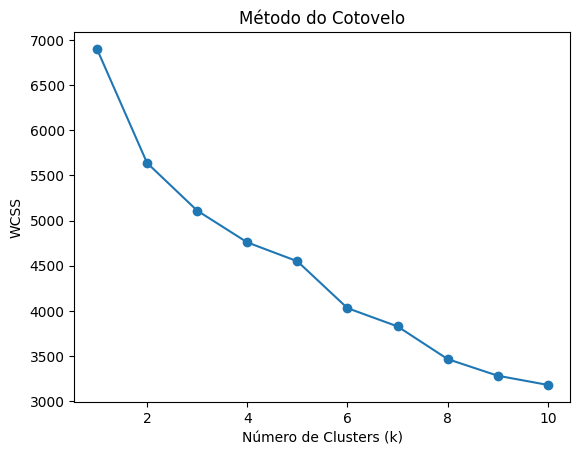

In [70]:
#Elbow
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Método do Cotovelo')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('WCSS')
plt.show()

In [62]:
#treinamento
k = 2
kmeans = KMeans(n_clusters=k, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

In [66]:
#Analise
df.groupby('Cluster').mean(numeric_only=True)

,Gender,Age,Debt,Married,BankCustomer,Industry,Ethnicity,YearsEmployed,PriorDefault,Employed,CreditScore,DriversLicense,Citizen,ZipCode,Income,Approved
Cluster,,,,,,,,,,,,,,,,
0,0.708920,29.041479,3.541526,0.718310,0.723005,4.962441,2.995305,1.098838,0.253521,0.133803,0.258216,0.431925,0.169014,194.392019,551.403756,0.197183
1,0.674242,35.504053,6.722841,0.829545,0.829545,6.450758,2.621212,4.038049,0.958333,0.901515,5.856061,0.500000,0.003788,158.208333,1769.310606,0.844697


In [68]:
# Análise de variáveis categóricas por cluster
for col in ['Industry', 'Ethnicity', 'Citizen']:
    print(f"\nDistribuição de {col} por cluster:")
    print(df.groupby('Cluster')[col].value_counts(normalize=True))


Distribuição de Industry por cluster:
Cluster  Industry
0        4           0.218310
         1           0.115023
         2           0.096244
         7           0.091549
         5           0.089202
         6           0.086854
         9           0.065728
         10          0.058685
         0           0.056338
         8           0.039906
         3           0.035211
         13          0.025822
         11          0.018779
         12          0.002347
1        4           0.200758
         9           0.189394
         13          0.102273
         7           0.094697
         8           0.090909
         6           0.060606
         0           0.053030
         2           0.049242
         5           0.049242
         1           0.037879
         3           0.037879
         10          0.018939
         11          0.007576
         12          0.007576
Name: proportion, dtype: float64

Distribuição de Ethnicity por cluster:
Cluster  Ethnicity
0        4 

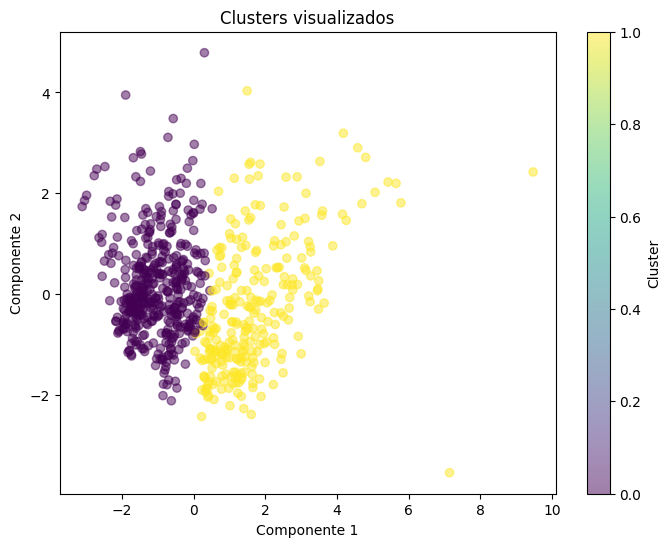

In [69]:
# Visualizar
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['Cluster'], cmap='viridis', alpha=0.5)
plt.title('Clusters visualizados')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.colorbar(label='Cluster')
plt.show()